<a href="https://colab.research.google.com/github/drmuruga/Chola-Eri-Simulation-RAG/blob/main/notebooks/Chola_Simulation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the necessary libraries for the Living Archive simulation
!pip install mesa pandas matplotlib networkx langchain chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

In [5]:
import mesa
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

class CholaAgent(mesa.Agent):
    """An agent representing a member of the Chola agrarian community."""
    def __init__(self, model, role):
        # In Mesa 3.0+, unique_id is automatically assigned by the model!
        super().__init__(model)
        self.role = role  # Roles: 'Sabha', 'Neerkatti', 'Cultivator'
        self.water_received = 0
        self.appeals_made = 0

    def step(self):
        # We will integrate the LangChain/RAG decision logic here in the next phase
        pass

class EriVillage(mesa.Model):
    """A model simulating the Chola Eri (Tank) system under ecological stress."""
    def __init__(self, n_sabha=5, n_neerkatti=5, n_cultivators=40):
        super().__init__() # Initializes the model
        self.current_water = 1000  # Baseline monsoon water units

        # We use a directed NetworkX graph to track interactions (who talks to whom)
        self.G = nx.DiGraph()

        # 1. Create Sabha Members
        for _ in range(n_sabha):
            agent = CholaAgent(self, "Sabha")
            self.G.add_node(agent.unique_id, role="Sabha")

        # 2. Create Neerkatti
        for _ in range(n_neerkatti):
            agent = CholaAgent(self, "Neerkatti")
            self.G.add_node(agent.unique_id, role="Neerkatti")

        # 3. Create Cultivators
        for _ in range(n_cultivators):
            agent = CholaAgent(self, "Cultivator")
            self.G.add_node(agent.unique_id, role="Cultivator")

        # In Mesa 3.0+, agents are automatically added to self.agents
        print(f"Initialized Eri Village with {len(self.agents)} agents.")

    def step(self):
        """Advance the model by one step."""
        # This replaces the old RandomActivation scheduler!
        self.agents.shuffle_do("step")

# Test the initialization
model = EriVillage()

Initialized Eri Village with 50 agents.


In [7]:
import chromadb

# 1. Initialize the ChromaDB client (runs entirely in-memory for Colab)
chroma_client = chromadb.Client()

# 2. Safely create or reset the collection for our historical corpus
try:
    chroma_client.delete_collection(name="chola_epigraphy")
except Exception:
    pass # Catch the new Rust backend NotFoundError if it doesn't exist yet

collection = chroma_client.create_collection(name="chola_epigraphy")

# 3. Load the purified historical facts (extracted directly from your Consensus CSVs)
historical_documents = [
    "During the Later Chola period, the management of irrigation networks was decentralized, vesting water rights and maintenance responsibilities in local village assemblies like the sabha and urar.",
    "The sabha and urar established intricate legal frameworks, civic cooperation, and dispute resolution mechanisms for agrarian water management.",
    "Epigraphical records show that during extreme scarcity, the Sabha had the absolute authority to penalize water hoarding, override standard distribution, and ration resources to cultivators.",
    "Traditional tank (Eri) cascade systems were constructed to combat frequent droughts, with the Neerkatti acting as the operational distributors of water to the cultivators."
]

# 4. Inject into the Vector Database with academic metadata
collection.add(
    documents=historical_documents,
    metadatas=[
        {"source": "Mala & Marisamy, 2025"},
        {"source": "Dk, 2025"},
        {"source": "Madhusudharsanan & Murugaiyan, 2019"},
        {"source": "Srivastava & Chinnasamy, 2021"}
    ],
    ids=["doc1", "doc2", "doc3", "doc4"]
)

print(f"Vector database initialized. Total historical records loaded: {collection.count()}")

# 5. Test the Retrieval Pipeline
test_query = "Who has the authority to resolve disputes and penalize hoarding during a drought?"
results = collection.query(query_texts=[test_query], n_results=1)

print(f"\n--- RAG RETRIEVAL TEST ---")
print(f"Query: {test_query}")
print(f"Retrieved Rule: {results['documents'][0][0]}")
print(f"Academic Source: {results['metadatas'][0][0]['source']}")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 93.8MiB/s]


Vector database initialized. Total historical records loaded: 4

--- RAG RETRIEVAL TEST ---
Query: Who has the authority to resolve disputes and penalize hoarding during a drought?
Retrieved Rule: Epigraphical records show that during extreme scarcity, the Sabha had the absolute authority to penalize water hoarding, override standard distribution, and ration resources to cultivators.
Academic Source: Madhusudharsanan & Murugaiyan, 2019


In [9]:
import random

class CholaAgent(mesa.Agent):
    def __init__(self, model, role):
        super().__init__(model)
        self.role = role
        self.water_received = 0
        self.appeals_made = 0

    def step(self):
        # Only Cultivators actively request water every step
        if self.role == "Cultivator":
            neerkattis = [a for a in self.model.agents if a.role == "Neerkatti"]
            if neerkattis:
                target_neerkatti = random.choice(neerkattis)

                # 1. Log the attempt to get water
                self.model.G.add_edge(self.unique_id, target_neerkatti.unique_id,
                                      interaction="request_water", time=self.model.time_step)

                # 2. Check if the Neerkatti has water to give
                if self.model.current_water >= 10:
                    self.model.current_water -= 10
                    self.water_received += 10
                    self.model.G.add_edge(target_neerkatti.unique_id, self.unique_id,
                                          interaction="grant_water", time=self.model.time_step)
                else:
                    # 3. DROUGHT PHASE: Neerkatti denies water. Cultivator must appeal to the Sabha.
                    self.model.G.add_edge(target_neerkatti.unique_id, self.unique_id,
                                          interaction="deny_water", time=self.model.time_step)

                    sabhas = [a for a in self.model.agents if a.role == "Sabha"]
                    if sabhas:
                        target_sabha = random.choice(sabhas)
                        self.appeals_made += 1
                        self.model.G.add_edge(self.unique_id, target_sabha.unique_id,
                                              interaction="appeal_to_sabha", time=self.model.time_step)

                        # The Sabha agent queries the RAG database to make a historically grounded decision
                        query = "What action does the Sabha take during extreme water scarcity?"
                        results = collection.query(query_texts=[query], n_results=1)
                        retrieved_rule = results['documents'][0][0]

                        # Sabha enforces rationing based strictly on the retrieved text
                        self.model.G.add_edge(target_sabha.unique_id, self.unique_id,
                                              interaction="rationing_enforced",
                                              historical_basis=retrieved_rule,
                                              time=self.model.time_step)

class EriVillage(mesa.Model):
    def __init__(self, n_sabha=5, n_neerkatti=5, n_cultivators=40):
        super().__init__()
        self.current_water = 1000
        self.time_step = 0
        self.G = nx.DiGraph()

        for _ in range(n_sabha):
            agent = CholaAgent(self, "Sabha")
            self.G.add_node(agent.unique_id, role="Sabha")
        for _ in range(n_neerkatti):
            agent = CholaAgent(self, "Neerkatti")
            self.G.add_node(agent.unique_id, role="Neerkatti")
        for _ in range(n_cultivators):
            agent = CholaAgent(self, "Cultivator")
            self.G.add_node(agent.unique_id, role="Cultivator")

    def step(self):
        self.time_step += 1

        # ECOLOGICAL PERTURBATION: The Monsoon Fails at t=50
        if self.time_step < 50:
            self.current_water = 1000  # Surplus baseline
        else:
            self.current_water = 150   # 85% reduction in available water units

        self.agents.shuffle_do("step")

print("Simulation Engine Compiled Successfully.")

Simulation Engine Compiled Successfully.


In [10]:
# 1. Instantiate the village environment
village_sim = EriVillage()

# Lists to track the timeline metrics for our quantitative analysis
timeline_steps = []
water_levels = []
total_appeals_logged = []

print("Starting simulation execution...")
print("--------------------------------")

# 2. Run the simulation loop for 100 iterations
for step_idx in range(100):
    village_sim.step()

    # Calculate current system metrics
    total_appeals = sum(a.appeals_made for a in village_sim.agents if a.role == "Cultivator")

    # Track metrics over time
    timeline_steps.append(village_sim.time_step)
    water_levels.append(village_sim.current_water)
    total_appeals_logged.append(total_appeals)

    # Print status checkpoints at key phases
    if village_sim.time_step in [1, 25, 49, 50, 75, 100]:
        print(f"Time Step {village_sim.time_step:03d} | Available Water: {village_sim.current_water:04d} units | Active Sabha Appeals: {total_appeals}")

print("--------------------------------")
print("Simulation complete.")
print(f"Total topological network interactions recorded in graph: {village_sim.G.number_of_edges()} edges.")

Starting simulation execution...
--------------------------------
Time Step 001 | Available Water: 0600 units | Active Sabha Appeals: 0
Time Step 025 | Available Water: 0600 units | Active Sabha Appeals: 0
Time Step 049 | Available Water: 0600 units | Active Sabha Appeals: 0
Time Step 050 | Available Water: 0000 units | Active Sabha Appeals: 25
Time Step 075 | Available Water: 0000 units | Active Sabha Appeals: 650
Time Step 100 | Available Water: 0000 units | Active Sabha Appeals: 1275
--------------------------------
Simulation complete.
Total topological network interactions recorded in graph: 800 edges.


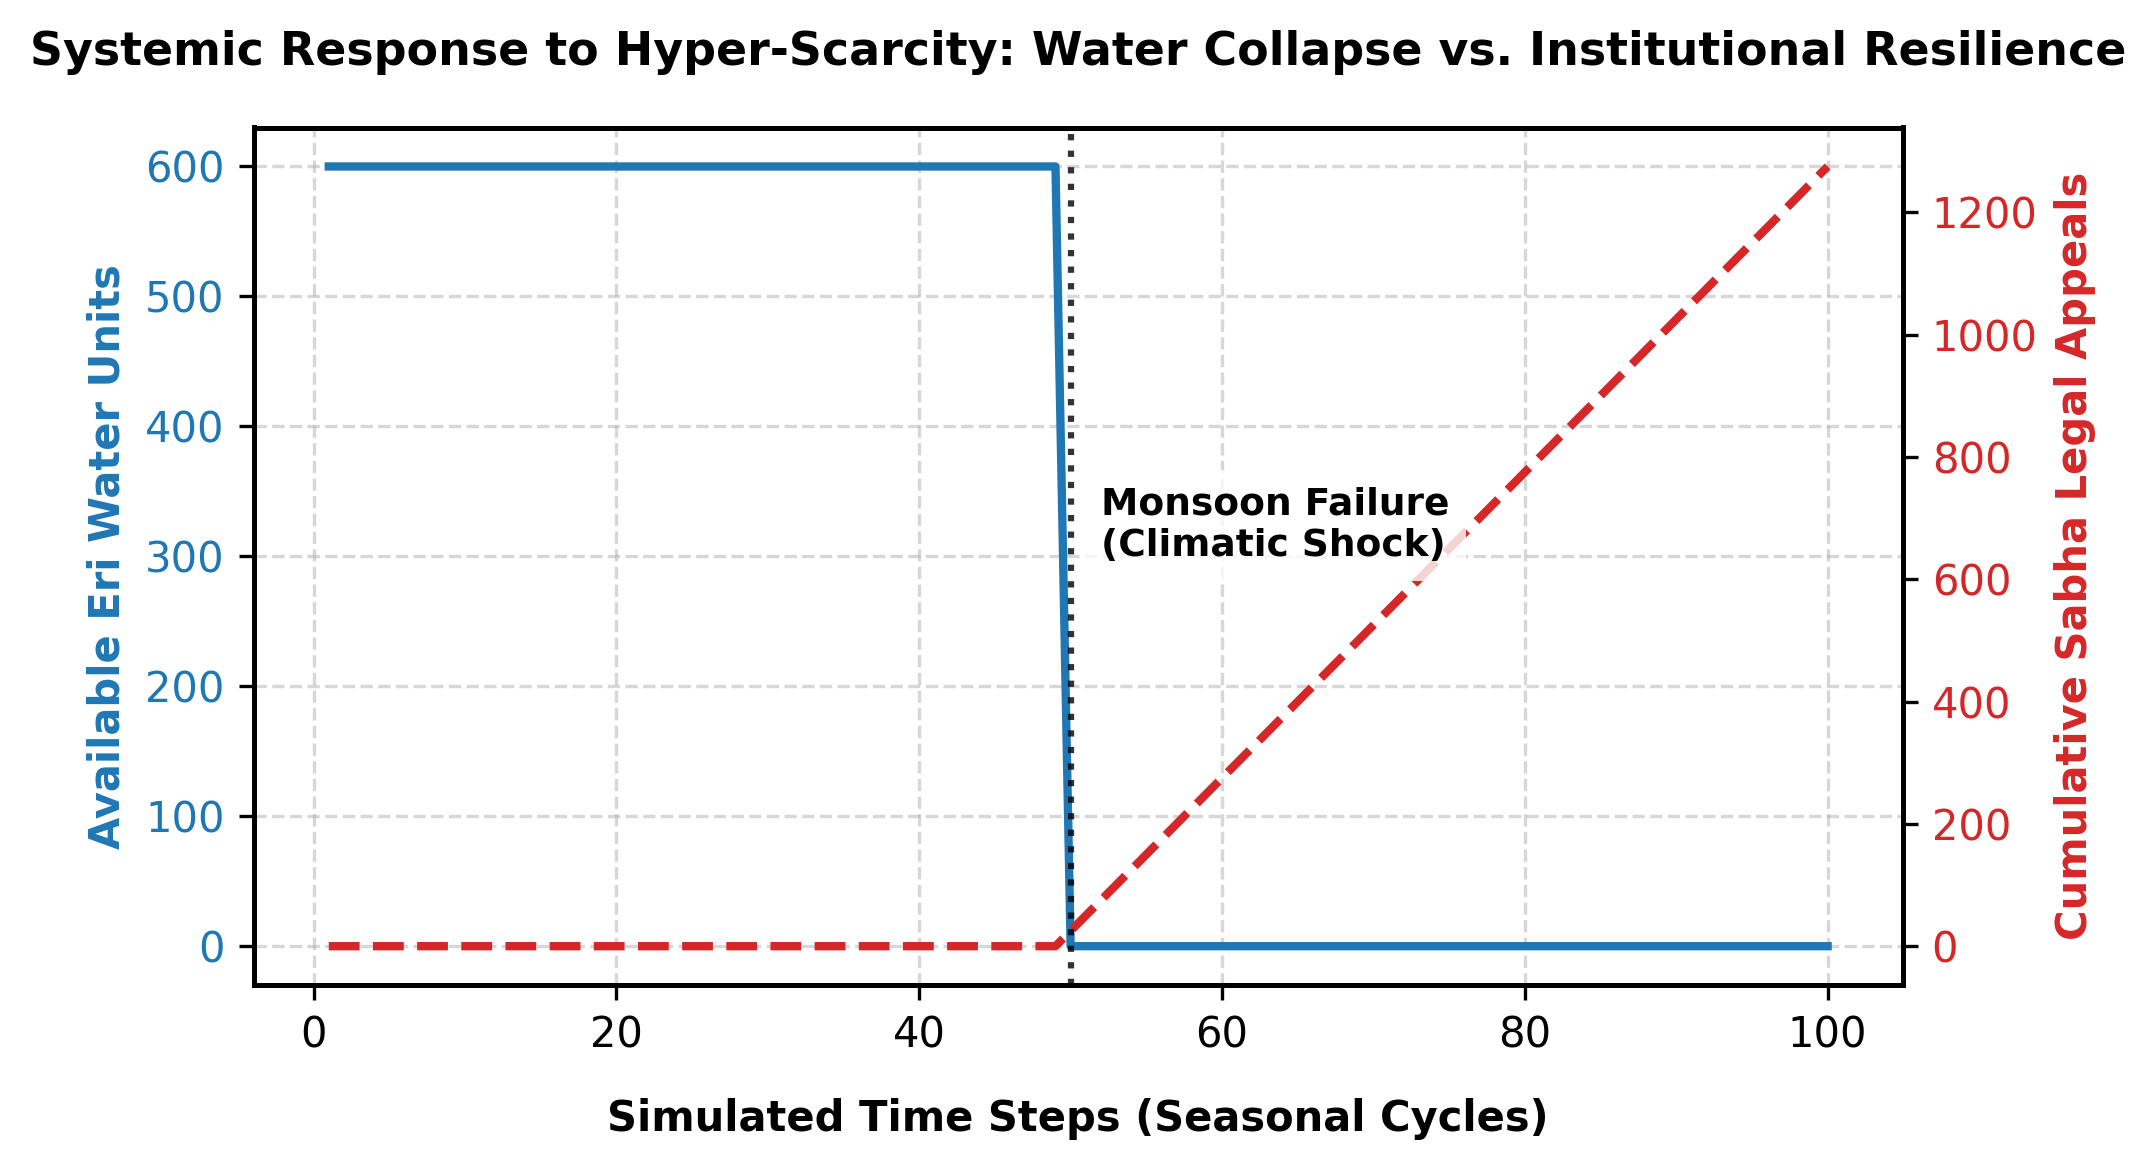

In [11]:
# Set high-fidelity font and structural parameters for publication
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2

fig, ax1 = plt.subplots(figsize=(7, 4), dpi=300)

# Plot Water Levels on the primary Y-axis
color_water = '#1f77b4'
ax1.set_xlabel('Simulated Time Steps (Seasonal Cycles)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Available Eri Water Units', color=color_water, fontweight='bold')
line1 = ax1.plot(timeline_steps, water_levels, color=color_water, linewidth=2, label='Water Volume')
ax1.tick_params(axis='y', labelcolor=color_water)
ax1.grid(True, linestyle='--', alpha=0.5)

# Create a secondary Y-axis to overlay the RAG Legal Appeals
ax2 = ax1.twinx()
color_appeals = '#d62728'
ax2.set_ylabel('Cumulative Sabha Legal Appeals', color=color_appeals, fontweight='bold')
line2 = ax2.plot(timeline_steps, total_appeals_logged, color=color_appeals, linewidth=2, linestyle='--', label='Sabha Appeals')
ax2.tick_params(axis='y', labelcolor=color_appeals)

# Add a vertical structural marker showing the exact moment the monsoon fails
plt.axvline(x=50, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
plt.text(52, max(total_appeals_logged)*0.5, 'Monsoon Failure\n(Climatic Shock)',
         fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title and Layout Optimization
plt.title('Systemic Response to Hyper-Scarcity: Water Collapse vs. Institutional Resilience',
          fontsize=11, fontweight='bold', pad=15)
fig.tight_layout()

# Save directly to your workspace as a high-res PDF ready for LaTeX ingestion
plt.savefig('systemic_drought_response.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# 1. Export the simulation timeline metrics to a clean CSV
simulation_metrics = pd.DataFrame({
    'Time_Step': timeline_steps,
    'Available_Water': water_levels,
    'Sabha_Appeals': total_appeals_logged
})
simulation_metrics.to_csv('simulation_timeline_log.csv', index=False)
print("Saved: simulation_timeline_log.csv (Move this to your /logs folder on GitHub)")

# 2. Export the NetworkX Graph structure to a GEXF file for Gephi/Network analysis
nx.write_gexf(village_sim.G, "chola_village_interaction_network.gexf")
print("Saved: chola_village_interaction_network.gexf (Move this to your /graphs folder on GitHub)")

Saved: simulation_timeline_log.csv (Move this to your /logs folder on GitHub)
Saved: chola_village_interaction_network.gexf (Move this to your /graphs folder on GitHub)


In [16]:
!pip install -q geopandas shapely

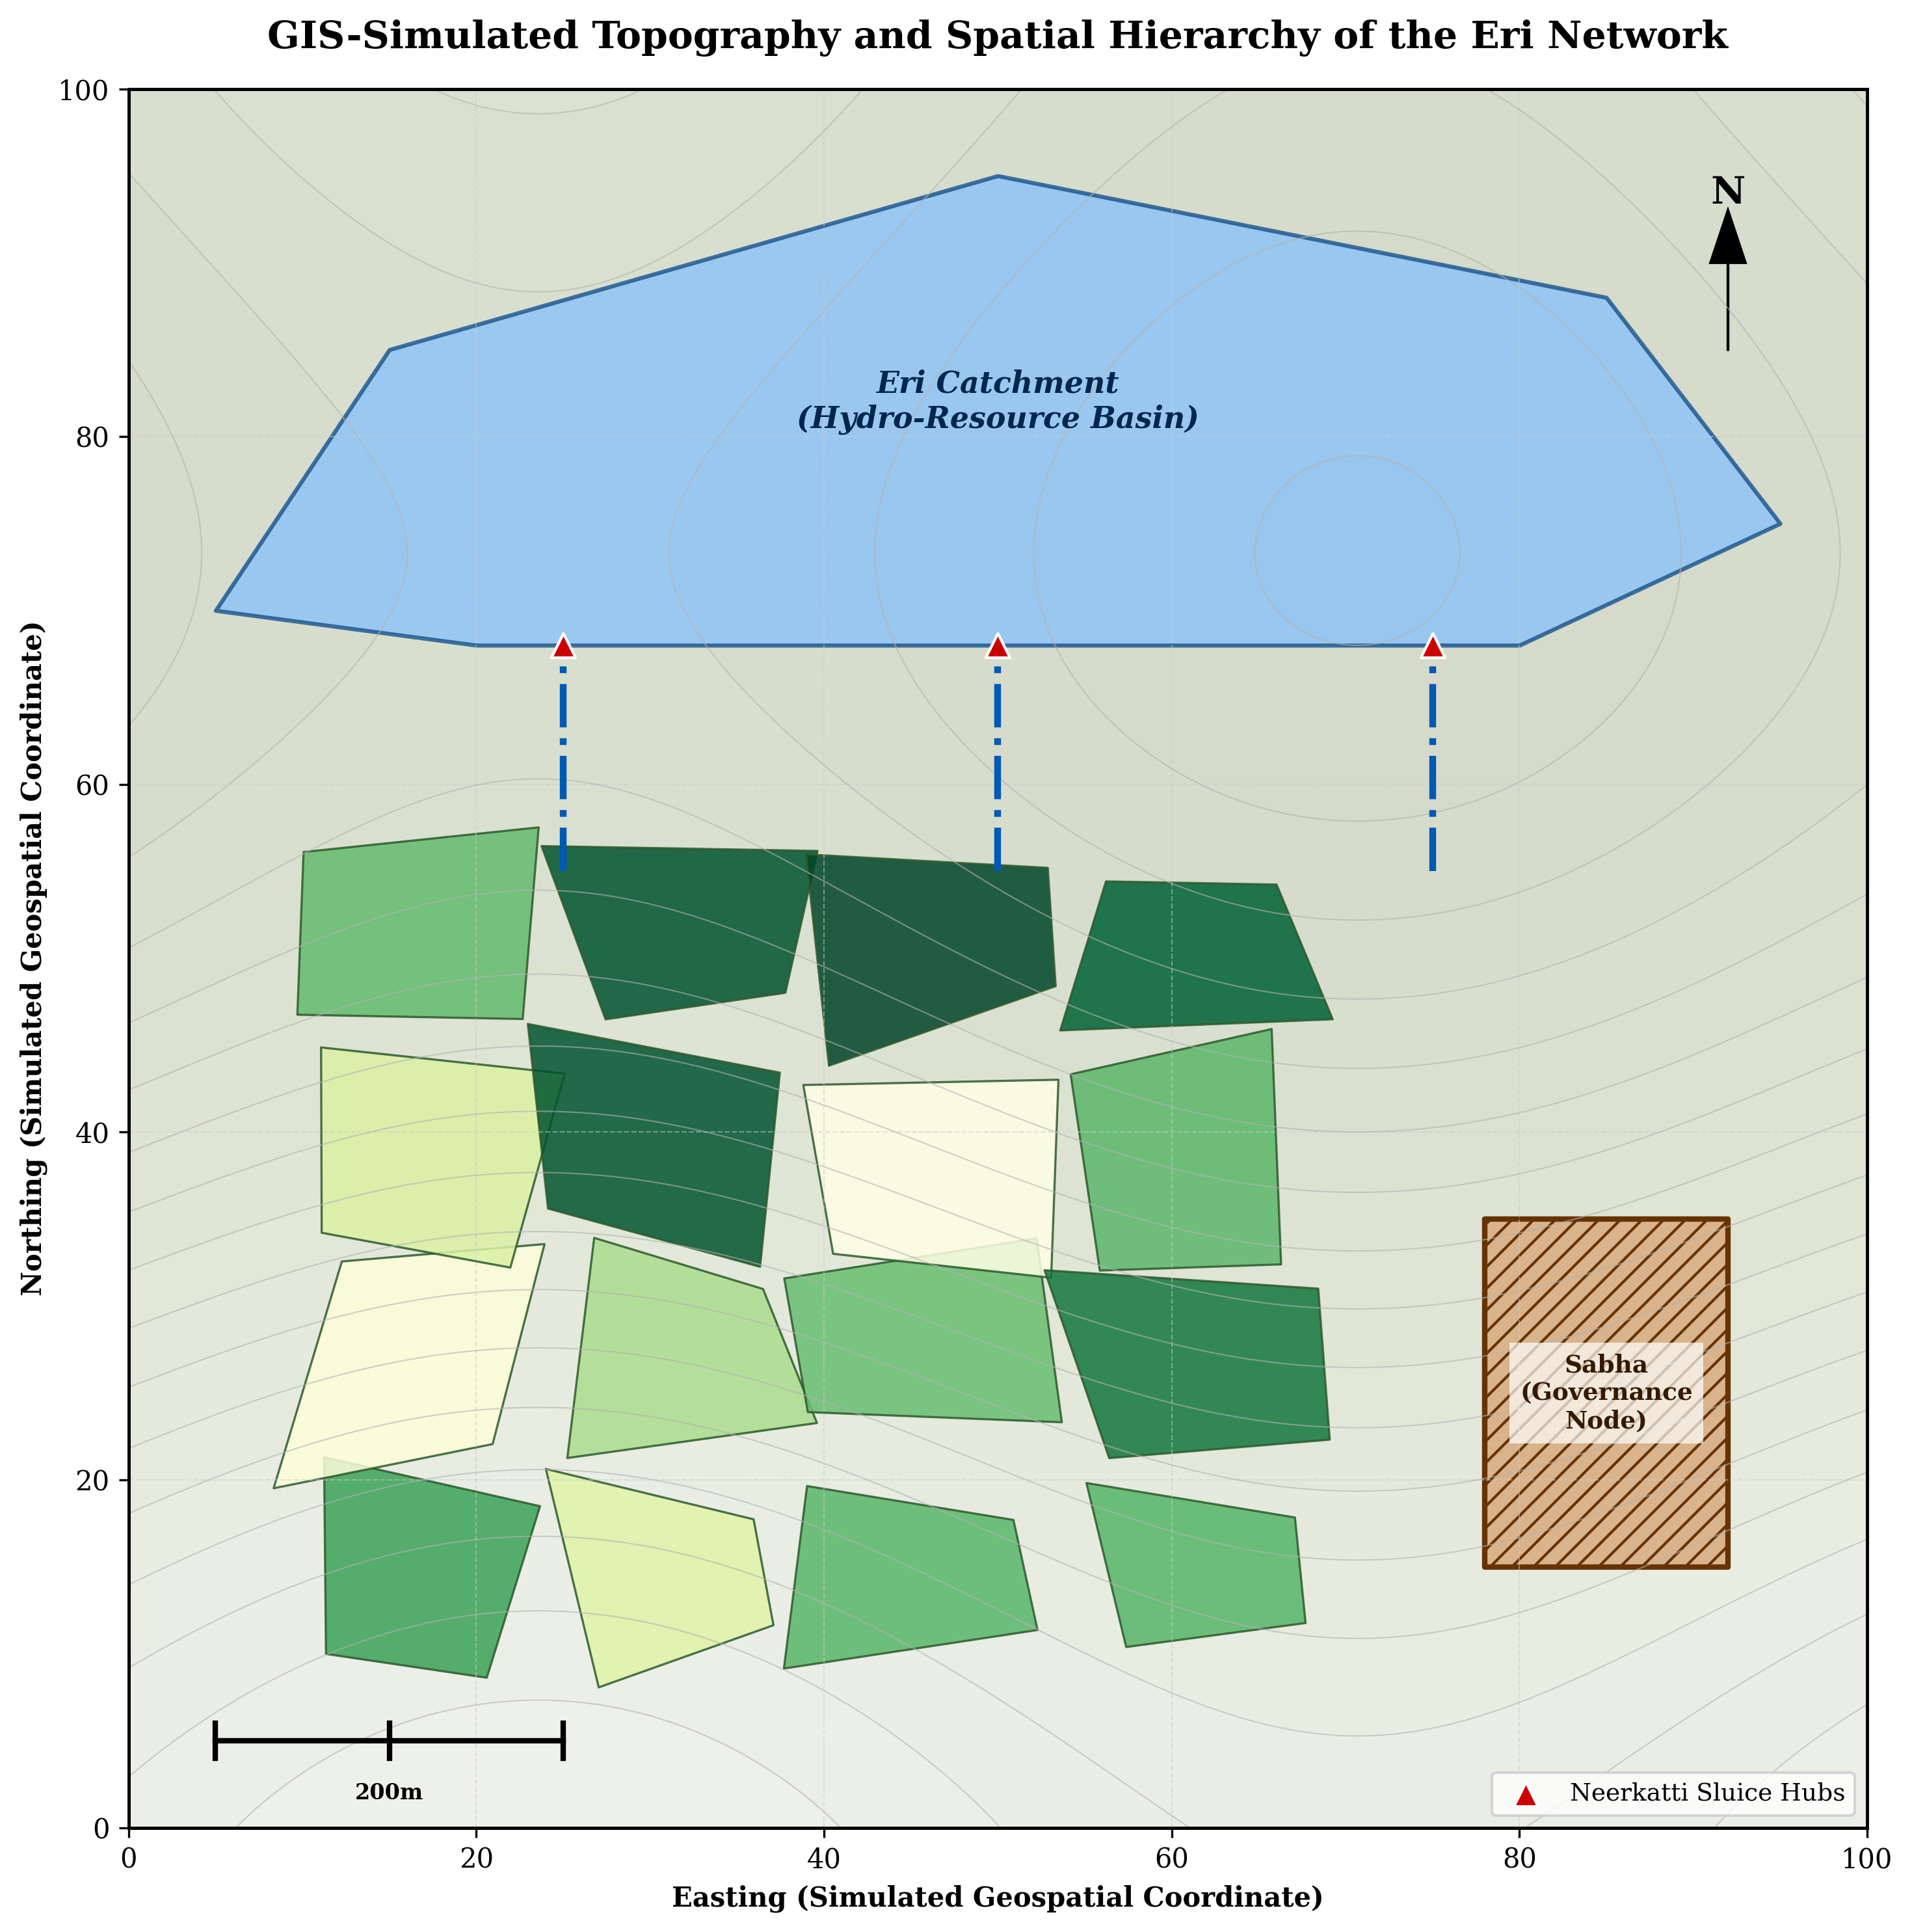

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Polygon, Point, LineString
import geopandas as gpd

# 1. Initialize High-Fidelity GIS Canvas
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
ax.set_aspect('equal')
ax.set_facecolor('#e9ecef')

# 2. Generate Synthetic Digital Elevation Model (DEM) for Terrain
x = np.linspace(0, 100, 200)
y = np.linspace(0, 100, 200)
X, Y = np.meshgrid(x, y)
# Create realistic rolling topography (elevation decreases towards the fields)
Z = 40 + 5 * np.sin(X/15) + 12 * np.cos(Y/20) - 0.3 * Y

terrain_cmap = LinearSegmentedColormap.from_list('terrain', ['#d0d6c4', '#e0e6d4', '#f0f2eb'])
contour = ax.contourf(X, Y, Z, levels=20, cmap=terrain_cmap, alpha=0.9)
ax.contour(X, Y, Z, levels=20, colors='#b3b3b3', linewidths=0.5, alpha=0.6)

# 3. Construct True Spatial Geometries (Shapely)
# The Eri Catchment (Organic polygon, not a perfect rectangle)
eri_coords = [(5, 70), (15, 85), (50, 95), (85, 88), (95, 75), (80, 68), (20, 68)]
eri_poly = Polygon(eri_coords)

# Sabha Governance Complex
sabha_poly = Polygon([(78, 15), (92, 15), (92, 35), (78, 35)])

# Agrarian Parcels (Irregular quadrilaterals simulating historical land division)
fields = []
np.random.seed(10) # Seed for reproducible irregularity
for i in range(10, 70, 15):
    for j in range(10, 50, 12):
        # Apply mathematical perturbations to corners so fields look organic
        dx = np.random.uniform(-2.5, 2.5, 4)
        dy = np.random.uniform(-2.5, 2.5, 4)
        field = Polygon([
            (i+dx[0], j+dy[0]),
            (i+13+dx[1], j+dy[1]),
            (i+13+dx[2], j+10+dy[2]),
            (i+dx[3], j+10+dy[3])
        ])
        fields.append(field)

# Sluice Channels
sluices = [LineString([(25, 55), (25, 68)]),
           LineString([(50, 55), (50, 68)]),
           LineString([(75, 55), (75, 68)])]

# 4. Convert to Geopandas DataFrames for GIS rendering
gdf_eri = gpd.GeoDataFrame(index=[0], geometry=[eri_poly])
gdf_sabha = gpd.GeoDataFrame(index=[0], geometry=[sabha_poly])
gdf_fields = gpd.GeoDataFrame(geometry=fields)
gdf_sluices = gpd.GeoDataFrame(geometry=sluices)

# Simulate crop yield data for choropleth rendering
gdf_fields['yield_index'] = np.random.uniform(0.4, 1.0, len(fields))

# 5. Layered GIS Plotting
# Plot fields as a choropleth map (darker green = higher simulated yield)
gdf_fields.plot(ax=ax, column='yield_index', cmap='YlGn', edgecolor='#2d5a2d', linewidth=0.8, alpha=0.85)

# Plot the water body with distinct GIS hydro-styling
gdf_eri.plot(ax=ax, color='#80bfff', edgecolor='#004080', linewidth=1.5, alpha=0.7)

# Plot Governance node with architectural hatching
gdf_sabha.plot(ax=ax, color='#d9b38c', edgecolor='#663300', linewidth=2, hatch='///')

# Plot Infrastructure (Sluice Channels)
gdf_sluices.plot(ax=ax, color='#0059b3', linewidth=2.5, linestyle='-.')

# Operational Nodes (Neerkatti represented as standard GIS infrastructure markers)
ax.scatter([25, 50, 75], [68, 68, 68], c='#cc0000', s=80, edgecolors='white', zorder=5, marker='^', label='Neerkatti Sluice Hubs')

# 6. Professional Cartographic Annotations
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Easting (Simulated Geospatial Coordinate)', fontsize=10, fontweight='bold')
ax.set_ylabel('Northing (Simulated Geospatial Coordinate)', fontsize=10, fontweight='bold')

ax.text(50, 82, 'Eri Catchment\n(Hydro-Resource Basin)', ha='center', va='center', fontsize=11, fontweight='bold', color='#00264d', style='italic')
ax.text(85, 25, 'Sabha\n(Governance\nNode)', ha='center', va='center', fontsize=9, fontweight='bold', color='#331a00', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Map Scale and North Arrow
ax.plot([5, 25], [5, 5], color='black', lw=2)
ax.plot([5, 5], [4, 6], color='black', lw=2)
ax.plot([15, 15], [4, 6], color='black', lw=2)
ax.plot([25, 25], [4, 6], color='black', lw=2)
ax.text(15, 2, '200m', ha='center', va='center', fontsize=8, fontweight='bold')

ax.arrow(92, 85, 0, 5, head_width=2, head_length=3, fc='black', ec='black')
ax.text(92, 94, 'N', ha='center', va='center', fontsize=14, fontweight='bold')

# Legend and Layout Optimization
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
plt.title('GIS-Simulated Topography and Spatial Hierarchy of the Eri Network', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chola_village_gis_map.pdf', dpi=300, bbox_inches='tight')
plt.show()